# TRA Tax Revenue Prediction Project

## Project Overview

This project aims to analyze economic indicators for Tanzania and develop a machine learning model to predict **Tax Revenue (% of GDP)**.

The analysis uses World Bank economic data covering multiple countries and years. The dataset is first explored and then filtered to focus specifically on Tanzania.


In [7]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print("TRA Tax Revenue Prediction Project")
print("Environment is working!")

TRA Tax Revenue Prediction Project
Environment is working!


## 1. Loading the Dataset

The World Bank dataset is loaded into a pandas DataFrame.

The dataset contains economic indicators for multiple countries across different years. The main target variable for this project is **Tax Revenue (% of GDP)**.

In [8]:
import pandas as pd

data = pd.read_csv("archive/world_bank_data_2025.csv")

data.head()

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
0,Aruba,aw,2010,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,NaN,NaN,NaN,2.313385e+09,NaN
1,Aruba,aw,2011,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,NaN,NaN,NaN,2.391841e+09,NaN
2,Aruba,aw,2012,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,NaN,NaN,NaN,2.499118e+09,NaN
3,Aruba,aw,2013,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,NaN,NaN,NaN,2.563517e+09,NaN
4,Aruba,aw,2014,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,NaN,NaN,NaN,2.688102e+09,NaN


## 2. Initial Dataset Inspection

Before modeling, the structure and size of the dataset are examined.

This helps determine how many observations and variables are available for the analysis.

In [9]:
data.shape

(3472, 16)

## 3. Dataset Structure and Data Types

The `info()` output is used to examine the dataset's columns, data types, and number of non-null observations.

This step is important because the dataset contains missing values in several economic indicators, which must be considered during data preparation.

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     3472 non-null   str    
 1   country_id                       3472 non-null   str    
 2   year                             3472 non-null   int64  
 3   Inflation (CPI %)                2694 non-null   float64
 4   GDP (Current USD)                2933 non-null   float64
 5   GDP per Capita (Current USD)     2938 non-null   float64
 6   Unemployment Rate (%)            2795 non-null   float64
 7   Interest Rate (Real, %)          1735 non-null   float64
 8   Inflation (GDP Deflator, %)      2904 non-null   float64
 9   GDP Growth (% Annual)            2912 non-null   float64
 10  Current Account Balance (% GDP)  2563 non-null   float64
 11  Government Expense (% of GDP)    1820 non-null   float64
 12  Government Revenue (% of GDP)  

## 4. Focusing the Analysis on Tanzania

Although the original dataset contains observations from many countries, this project focuses specifically on Tanzania.

Filtering the dataset to Tanzania allows the model to learn the historical relationship between Tanzania's economic indicators and its tax revenue.

In [11]:
tanzania = data[data["country_name"] == "Tanzania"]

tanzania

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
3184,Tanzania,tz,2010,6.200156,3.201289e+10,736.530151,3.029,4.674687,9.428716,6.336523,-6.905905,13.193082,10.396665,9.912262,3.143581e+10,NaN
3185,Tanzania,tz,2011,12.690969,3.465714e+10,775.392761,3.470,2.464304,12.198423,7.672155,-12.640833,14.376047,10.320133,9.793982,3.401343e+10,NaN
3186,Tanzania,tz,2012,16.001094,3.965039e+10,861.969910,3.222,4.591414,10.483894,4.500154,-9.493817,14.017908,11.323466,10.433004,3.908012e+10,NaN
3187,Tanzania,tz,2013,7.870724,4.564886e+10,963.057129,2.930,5.648642,9.666184,6.781586,-10.926790,14.831074,11.362831,10.721923,4.494573e+10,NaN
3188,Tanzania,tz,2014,6.131614,4.998673e+10,1022.748413,2.125,9.655734,6.050846,6.732462,-9.975750,16.079444,12.237934,11.363797,4.945365e+10,NaN
3189,Tanzania,tz,2015,5.588170,4.741392e+10,939.127319,2.159,7.912936,7.591364,6.160629,-5.522795,14.870078,11.383121,10.492495,4.668422e+10,NaN
3190,Tanzania,tz,2016,5.174766,4.977441e+10,953.010742,2.230,7.896286,7.472034,6.867116,-2.446517,13.368853,12.402698,11.390340,4.881719e+10,NaN
3191,Tanzania,tz,2017,5.318716,5.327488e+10,986.674011,2.303,14.746999,2.638124,6.762277,-2.773407,15.738653,13.582469,11.836719,5.233943e+10,NaN
3192,Tanzania,tz,2018,3.494458,5.700371e+10,1023.106262,2.393,13.948578,3.041362,5.468082,-4.050309,14.574863,13.906033,11.695083,5.636503e+10,NaN
3193,Tanzania,tz,2019,3.464281,6.102673e+10,1063.322510,2.496,14.362892,2.280409,5.800000,-2.196155,15.375293,13.270019,11.019117,6.001299e+10,NaN


## 5. Time Coverage

The minimum and maximum years are checked to understand the time period covered by the dataset.

The Tanzania observations span from 2010 to 2025, with tax revenue observations available through 2023. The later years are therefore relevant for forecasting.

In [12]:
data["year"].min(), data["year"].max()

(np.int64(2010), np.int64(2025))

## 6. Exploring the Target Variable

The distribution of **Tax Revenue (% of GDP)** is examined using descriptive statistics.

This provides information about the central tendency, variability, minimum, maximum, and overall range of the target variable.

In [13]:
data["Tax Revenue (% of GDP)"].describe()

count    1833.000000
mean       16.969924
std         8.218539
min         0.000063
25%        12.285344
50%        16.321438
75%        21.448658
max       147.640196
Name: Tax Revenue (% of GDP), dtype: float64

## 7. Historical Tax Revenue Trend in Tanzania

The historical tax revenue values for Tanzania are visualized over time.

This plot helps identify the general trend and year-to-year variation in tax revenue as a percentage of GDP before developing the prediction models.

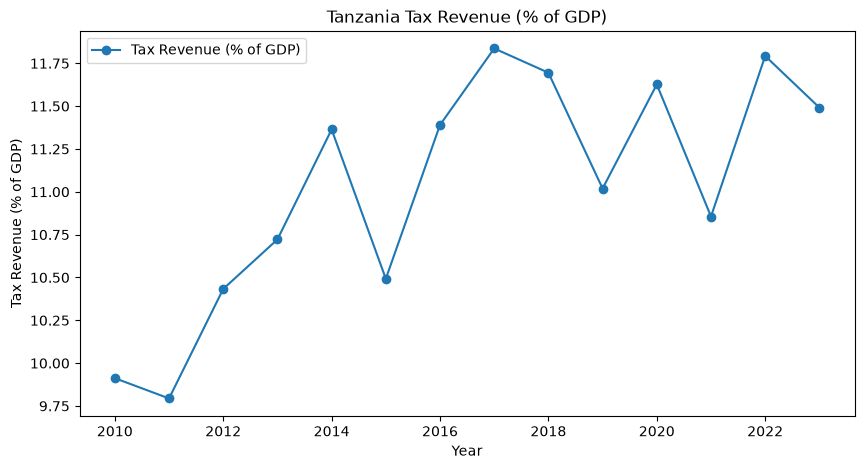

In [14]:
tanzania = data[data["country_name"] == "Tanzania"].copy()

tanzania.plot(
    x="year",
    y="Tax Revenue (% of GDP)",
    marker="o",
    figsize=(10, 5)
)

plt.title("Tanzania Tax Revenue (% of GDP)")
plt.ylabel("Tax Revenue (% of GDP)")
plt.xlabel("Year")
plt.show()

## 8. Relationship Between Economic Indicators and Tax Revenue

Correlation analysis is used to examine the linear relationship between the numerical economic indicators and **Tax Revenue (% of GDP)**.

This provides an initial understanding of which variables may be associated with changes in tax revenue.

Correlation is used here as an exploratory technique and does not by itself establish causation.

In [15]:
data.corr(numeric_only=True)["Tax Revenue (% of GDP)"].sort_values(ascending=False)

Tax Revenue (% of GDP)             1.000000
Government Revenue (% of GDP)      0.798062
Government Expense (% of GDP)      0.578602
Current Account Balance (% GDP)    0.521580
Public Debt (% of GDP)             0.249167
GDP per Capita (Current USD)       0.216559
Unemployment Rate (%)              0.156635
year                              -0.006990
GDP Growth (% Annual)             -0.045543
Inflation (CPI %)                 -0.085487
Gross National Income (USD)       -0.097913
GDP (Current USD)                 -0.098356
Inflation (GDP Deflator, %)       -0.098675
Interest Rate (Real, %)           -0.132236
Name: Tax Revenue (% of GDP), dtype: float64

In [16]:
tz_data = data[data["country_id"] == "tz"].copy()

tz_data = tz_data.sort_values("year")

tz_data

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
3184,Tanzania,tz,2010,6.200156,3.201289e+10,736.530151,3.029,4.674687,9.428716,6.336523,-6.905905,13.193082,10.396665,9.912262,3.143581e+10,NaN
3185,Tanzania,tz,2011,12.690969,3.465714e+10,775.392761,3.470,2.464304,12.198423,7.672155,-12.640833,14.376047,10.320133,9.793982,3.401343e+10,NaN
3186,Tanzania,tz,2012,16.001094,3.965039e+10,861.969910,3.222,4.591414,10.483894,4.500154,-9.493817,14.017908,11.323466,10.433004,3.908012e+10,NaN
3187,Tanzania,tz,2013,7.870724,4.564886e+10,963.057129,2.930,5.648642,9.666184,6.781586,-10.926790,14.831074,11.362831,10.721923,4.494573e+10,NaN
3188,Tanzania,tz,2014,6.131614,4.998673e+10,1022.748413,2.125,9.655734,6.050846,6.732462,-9.975750,16.079444,12.237934,11.363797,4.945365e+10,NaN
3189,Tanzania,tz,2015,5.588170,4.741392e+10,939.127319,2.159,7.912936,7.591364,6.160629,-5.522795,14.870078,11.383121,10.492495,4.668422e+10,NaN
3190,Tanzania,tz,2016,5.174766,4.977441e+10,953.010742,2.230,7.896286,7.472034,6.867116,-2.446517,13.368853,12.402698,11.390340,4.881719e+10,NaN
3191,Tanzania,tz,2017,5.318716,5.327488e+10,986.674011,2.303,14.746999,2.638124,6.762277,-2.773407,15.738653,13.582469,11.836719,5.233943e+10,NaN
3192,Tanzania,tz,2018,3.494458,5.700371e+10,1023.106262,2.393,13.948578,3.041362,5.468082,-4.050309,14.574863,13.906033,11.695083,5.636503e+10,NaN
3193,Tanzania,tz,2019,3.464281,6.102673e+10,1063.322510,2.496,14.362892,2.280409,5.800000,-2.196155,15.375293,13.270019,11.019117,6.001299e+10,NaN


## 9. Missing-Value Analysis

After isolating Tanzania, missing values are examined for each variable.

This step is important because machine learning models generally require complete feature values. Variables with substantial or complete missingness must therefore be handled carefully before modeling.

In [17]:
tz_data.isnull().sum()

country_name                        0
country_id                          0
year                                0
Inflation (CPI %)                   1
GDP (Current USD)                   2
GDP per Capita (Current USD)        2
Unemployment Rate (%)               1
Interest Rate (Real, %)             5
Inflation (GDP Deflator, %)         2
GDP Growth (% Annual)               2
Current Account Balance (% GDP)     2
Government Expense (% of GDP)       2
Government Revenue (% of GDP)       2
Tax Revenue (% of GDP)              2
Gross National Income (USD)         2
Public Debt (% of GDP)             16
dtype: int64

In [18]:
tz_data[tz_data.isnull().any(axis=1)]

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
3184,Tanzania,tz,2010,6.200156,3.201289e+10,736.530151,3.029,4.674687,9.428716,6.336523,-6.905905,13.193082,10.396665,9.912262,3.143581e+10,NaN
3185,Tanzania,tz,2011,12.690969,3.465714e+10,775.392761,3.470,2.464304,12.198423,7.672155,-12.640833,14.376047,10.320133,9.793982,3.401343e+10,NaN
3186,Tanzania,tz,2012,16.001094,3.965039e+10,861.969910,3.222,4.591414,10.483894,4.500154,-9.493817,14.017908,11.323466,10.433004,3.908012e+10,NaN
3187,Tanzania,tz,2013,7.870724,4.564886e+10,963.057129,2.930,5.648642,9.666184,6.781586,-10.926790,14.831074,11.362831,10.721923,4.494573e+10,NaN
3188,Tanzania,tz,2014,6.131614,4.998673e+10,1022.748413,2.125,9.655734,6.050846,6.732462,-9.975750,16.079444,12.237934,11.363797,4.945365e+10,NaN
3189,Tanzania,tz,2015,5.588170,4.741392e+10,939.127319,2.159,7.912936,7.591364,6.160629,-5.522795,14.870078,11.383121,10.492495,4.668422e+10,NaN
3190,Tanzania,tz,2016,5.174766,4.977441e+10,953.010742,2.230,7.896286,7.472034,6.867116,-2.446517,13.368853,12.402698,11.390340,4.881719e+10,NaN
3191,Tanzania,tz,2017,5.318716,5.327488e+10,986.674011,2.303,14.746999,2.638124,6.762277,-2.773407,15.738653,13.582469,11.836719,5.233943e+10,NaN
3192,Tanzania,tz,2018,3.494458,5.700371e+10,1023.106262,2.393,13.948578,3.041362,5.468082,-4.050309,14.574863,13.906033,11.695083,5.636503e+10,NaN
3193,Tanzania,tz,2019,3.464281,6.102673e+10,1063.322510,2.496,14.362892,2.280409,5.800000,-2.196155,15.375293,13.270019,11.019117,6.001299e+10,NaN


## 10. Preparing the Modeling Dataset

The **Public Debt (% of GDP)** variable is removed because it contains no usable observations for Tanzania in this dataset.

Removing a completely missing feature prevents it from interfering with the machine learning workflow.

In [19]:
tz_model = tz_data.drop(columns=["Public Debt (% of GDP)"]).copy()

tz_model

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD)
3184,Tanzania,tz,2010,6.200156,3.201289e+10,736.530151,3.029,4.674687,9.428716,6.336523,-6.905905,13.193082,10.396665,9.912262,3.143581e+10
3185,Tanzania,tz,2011,12.690969,3.465714e+10,775.392761,3.470,2.464304,12.198423,7.672155,-12.640833,14.376047,10.320133,9.793982,3.401343e+10
3186,Tanzania,tz,2012,16.001094,3.965039e+10,861.969910,3.222,4.591414,10.483894,4.500154,-9.493817,14.017908,11.323466,10.433004,3.908012e+10
3187,Tanzania,tz,2013,7.870724,4.564886e+10,963.057129,2.930,5.648642,9.666184,6.781586,-10.926790,14.831074,11.362831,10.721923,4.494573e+10
3188,Tanzania,tz,2014,6.131614,4.998673e+10,1022.748413,2.125,9.655734,6.050846,6.732462,-9.975750,16.079444,12.237934,11.363797,4.945365e+10
3189,Tanzania,tz,2015,5.588170,4.741392e+10,939.127319,2.159,7.912936,7.591364,6.160629,-5.522795,14.870078,11.383121,10.492495,4.668422e+10
3190,Tanzania,tz,2016,5.174766,4.977441e+10,953.010742,2.230,7.896286,7.472034,6.867116,-2.446517,13.368853,12.402698,11.390340,4.881719e+10
3191,Tanzania,tz,2017,5.318716,5.327488e+10,986.674011,2.303,14.746999,2.638124,6.762277,-2.773407,15.738653,13.582469,11.836719,5.233943e+10
3192,Tanzania,tz,2018,3.494458,5.700371e+10,1023.106262,2.393,13.948578,3.041362,5.468082,-4.050309,14.574863,13.906033,11.695083,5.636503e+10
3193,Tanzania,tz,2019,3.464281,6.102673e+10,1063.322510,2.496,14.362892,2.280409,5.800000,-2.196155,15.375293,13.270019,11.019117,6.001299e+10


In [20]:
tz_model.isnull().sum()

country_name                       0
country_id                         0
year                               0
Inflation (CPI %)                  1
GDP (Current USD)                  2
GDP per Capita (Current USD)       2
Unemployment Rate (%)              1
Interest Rate (Real, %)            5
Inflation (GDP Deflator, %)        2
GDP Growth (% Annual)              2
Current Account Balance (% GDP)    2
Government Expense (% of GDP)      2
Government Revenue (% of GDP)      2
Tax Revenue (% of GDP)             2
Gross National Income (USD)        2
dtype: int64

## 11. Identifying Observations with Known Target Values

The target variable, **Tax Revenue (% of GDP)**, is available for Tanzania from 2010 through 2023.

The observations with known target values are retained for model development and evaluation.

The 2024 and 2025 observations do not contain known tax revenue values and are therefore reserved for forecasting.

In [21]:
train_data = tz_model.dropna(subset=["Tax Revenue (% of GDP)"]).copy()

train_data

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD)
3184,Tanzania,tz,2010,6.200156,3.201289e+10,736.530151,3.029,4.674687,9.428716,6.336523,-6.905905,13.193082,10.396665,9.912262,3.143581e+10
3185,Tanzania,tz,2011,12.690969,3.465714e+10,775.392761,3.470,2.464304,12.198423,7.672155,-12.640833,14.376047,10.320133,9.793982,3.401343e+10
3186,Tanzania,tz,2012,16.001094,3.965039e+10,861.969910,3.222,4.591414,10.483894,4.500154,-9.493817,14.017908,11.323466,10.433004,3.908012e+10
3187,Tanzania,tz,2013,7.870724,4.564886e+10,963.057129,2.930,5.648642,9.666184,6.781586,-10.926790,14.831074,11.362831,10.721923,4.494573e+10
3188,Tanzania,tz,2014,6.131614,4.998673e+10,1022.748413,2.125,9.655734,6.050846,6.732462,-9.975750,16.079444,12.237934,11.363797,4.945365e+10
3189,Tanzania,tz,2015,5.588170,4.741392e+10,939.127319,2.159,7.912936,7.591364,6.160629,-5.522795,14.870078,11.383121,10.492495,4.668422e+10
3190,Tanzania,tz,2016,5.174766,4.977441e+10,953.010742,2.230,7.896286,7.472034,6.867116,-2.446517,13.368853,12.402698,11.390340,4.881719e+10
3191,Tanzania,tz,2017,5.318716,5.327488e+10,986.674011,2.303,14.746999,2.638124,6.762277,-2.773407,15.738653,13.582469,11.836719,5.233943e+10
3192,Tanzania,tz,2018,3.494458,5.700371e+10,1023.106262,2.393,13.948578,3.041362,5.468082,-4.050309,14.574863,13.906033,11.695083,5.636503e+10
3193,Tanzania,tz,2019,3.464281,6.102673e+10,1063.322510,2.496,14.362892,2.280409,5.800000,-2.196155,15.375293,13.270019,11.019117,6.001299e+10


In [22]:
train_data.isnull().sum()

country_name                       0
country_id                         0
year                               0
Inflation (CPI %)                  0
GDP (Current USD)                  0
GDP per Capita (Current USD)       0
Unemployment Rate (%)              0
Interest Rate (Real, %)            3
Inflation (GDP Deflator, %)        0
GDP Growth (% Annual)              0
Current Account Balance (% GDP)    0
Government Expense (% of GDP)      0
Government Revenue (% of GDP)      0
Tax Revenue (% of GDP)             0
Gross National Income (USD)        0
dtype: int64

In [23]:
train_data.shape

(14, 15)

## 12. Selecting Model Features

Economic indicators with usable observations are selected as input features for the initial machine learning model.

The target variable is **Tax Revenue (% of GDP)**.

The model is therefore trained to learn the relationship:

**Economic Indicators → Tax Revenue (% of GDP)**

In [24]:
features = [
    "Inflation (CPI %)",
    "GDP (Current USD)",
    "GDP per Capita (Current USD)",
    "Unemployment Rate (%)",
    "Inflation (GDP Deflator, %)",
    "GDP Growth (% Annual)",
    "Current Account Balance (% GDP)",
    "Government Expense (% of GDP)",
    "Government Revenue (% of GDP)",
    "Gross National Income (USD)"
]

X = train_data[features]
y = train_data["Tax Revenue (% of GDP)"]

## 13. Chronological Train-Test Split

Because this is a time-series forecasting problem, the data must be split chronologically rather than randomly.

The observations from **2010–2020** are used for training, while **2021–2023** are used for testing.

This approach prevents future observations from being used to train the model before evaluating it on earlier unseen periods.

In [25]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

In [26]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (11, 10)
X_test: (3, 10)
y_train: (11,)
y_test: (3,)


## 14. Baseline Linear Regression Model

Linear Regression is used as an initial machine learning baseline.

The model assumes a linear relationship between the selected economic features and Tanzania's tax revenue.

Its predictions are evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.,-0., 0.,..., 0., 0., 0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['Inflation (CPI %)','GDP (Current USD)','GDP per Capita (Current USD)', ...,'Government Expense (% of GDP)','Government Revenue (% of GDP)', 'Gross National Income (USD)']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.15
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [28]:
y_pred = model.predict(X_test)

y_pred

array([12.14100291, 12.3501572 , 12.49481436])

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 0.9486683387463124
RMSE: 0.9948516011176805
R²: -5.489729417360818


## 15. Naive Previous-Year Baseline

A simple baseline is created by using the previous year's tax revenue as the prediction for the current year.

This is an important benchmark for a time-series problem because tax revenue may have strong year-to-year persistence.

A more complex machine learning model should ideally perform better than this simple baseline.

In [30]:
y_naive_pred = y.shift(1).loc[y_test.index]

y_naive_pred

3195    11.626769
3196    10.855800
3197    11.792681
Name: Tax Revenue (% of GDP), dtype: float64

In [31]:
naive_mae = mean_absolute_error(y_test, y_naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, y_naive_pred))
naive_r2 = r2_score(y_test, y_naive_pred)

print("Naive MAE:", naive_mae)
print("Naive RMSE:", naive_rmse)
print("Naive R²:", naive_r2)

Naive MAE: 0.6696807116593005
Naive RMSE: 0.7217701150729652
Naive R²: -2.415920663821462


## 16. Time-Series Validation

Time-series cross-validation is considered to ensure that model evaluation respects the chronological order of observations.

Unlike ordinary random cross-validation, time-series validation keeps earlier observations in the training set and evaluates the model on later observations.

In [32]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    print("TRAIN:", train_index)
    print("TEST: ", test_index)
    

TRAIN: [0 1 2 3]
TEST:  [4 5]
TRAIN: [0 1 2 3 4 5]
TEST:  [6 7]
TRAIN: [0 1 2 3 4 5 6 7]
TEST:  [8 9]
TRAIN: [0 1 2 3 4 5 6 7 8 9]
TEST:  [10 11]
TRAIN: [ 0  1  2  3  4  5  6  7  8  9 10 11]
TEST:  [12 13]


In [33]:
for test_year in range(2017, 2024):
    train = train_data[train_data["year"] < test_year]
    test = train_data[train_data["year"] == test_year]

    print(
        f"Train: {train['year'].min()}–{train['year'].max()} | "
        f"Test: {test_year} | "
        f"Training rows: {len(train)}"
    )

Train: 2010–2016 | Test: 2017 | Training rows: 7
Train: 2010–2017 | Test: 2018 | Training rows: 8
Train: 2010–2018 | Test: 2019 | Training rows: 9
Train: 2010–2019 | Test: 2020 | Training rows: 10
Train: 2010–2020 | Test: 2021 | Training rows: 11
Train: 2010–2021 | Test: 2022 | Training rows: 12
Train: 2010–2022 | Test: 2023 | Training rows: 13


## 17. Walk-Forward Validation

Walk-forward validation is used to evaluate the model across multiple historical years.

For each test year, only observations from earlier years are used for training. The model then predicts the next unseen year.

This provides a more realistic evaluation of how the model would behave when making future forecasts.

In [34]:
from sklearn.linear_model import LinearRegression

walk_forward_results = []

for test_year in range(2017, 2024):

    train = train_data[train_data["year"] < test_year]
    test = train_data[train_data["year"] == test_year]

    X_train_wf = train[features]
    y_train_wf = train["Tax Revenue (% of GDP)"]

    X_test_wf = test[features]
    y_test_wf = test["Tax Revenue (% of GDP)"]

    model_wf = LinearRegression()
    model_wf.fit(X_train_wf, y_train_wf)

    prediction = model_wf.predict(X_test_wf)[0]

    walk_forward_results.append({
        "year": test_year,
        "actual": y_test_wf.iloc[0],
        "predicted": prediction
    })

walk_forward_results


[{'year': 2017,
  'actual': np.float64(11.8367190192838),
  'predicted': np.float64(11.403075475181506)},
 {'year': 2018,
  'actual': np.float64(11.695083058288),
  'predicted': np.float64(11.803864480756918)},
 {'year': 2019,
  'actual': np.float64(11.0191174811563),
  'predicted': np.float64(12.24066549149164)},
 {'year': 2020,
  'actual': np.float64(11.6267688543522),
  'predicted': np.float64(11.94996515207717)},
 {'year': 2021,
  'actual': np.float64(10.8557996439654),
  'predicted': np.float64(12.141002914659634)},
 {'year': 2022,
  'actual': np.float64(11.7926807934669),
  'predicted': np.float64(11.796214406654238)},
 {'year': 2023,
  'actual': np.float64(11.4914890183773),
  'predicted': np.float64(11.873274500364342)}]

In [35]:
wf_actual = [result["actual"] for result in walk_forward_results]
wf_predicted = [result["predicted"] for result in walk_forward_results]

wf_mae = mean_absolute_error(wf_actual, wf_predicted)
wf_rmse = np.sqrt(mean_squared_error(wf_actual, wf_predicted))
wf_r2 = r2_score(wf_actual, wf_predicted)

print("Walk-forward MAE:", wf_mae)
print("Walk-forward RMSE:", wf_rmse)
print("Walk-forward R²:", wf_r2)

Walk-forward MAE: 0.5368130915000194
Walk-forward RMSE: 0.7165428506092597
Walk-forward R²: -3.016875123312574


In [36]:
wf_naive_pred = []

for test_year in range(2017, 2024):
    previous_year_value = train_data[
        train_data["year"] == test_year - 1
    ]["Tax Revenue (% of GDP)"].iloc[0]

    wf_naive_pred.append(previous_year_value)

In [37]:
wf_naive_mae = mean_absolute_error(wf_actual, wf_naive_pred)
wf_naive_rmse = np.sqrt(mean_squared_error(wf_actual, wf_naive_pred))
wf_naive_r2 = r2_score(wf_actual, wf_naive_pred)

print("Naive Walk-forward MAE:", wf_naive_mae)
print("Naive Walk-forward RMSE:", wf_naive_rmse)
print("Naive Walk-forward R²:", wf_naive_r2)

Naive Walk-forward MAE: 0.5543820183967715
Naive Walk-forward RMSE: 0.6104261954417688
Naive Walk-forward R²: -1.9152131953837408


## 18. Ridge Regression

Ridge Regression is introduced as an alternative to ordinary Linear Regression.

Ridge adds L2 regularization, which penalizes large model coefficients and can help reduce overfitting, particularly when predictors are correlated.

The regularization strength is controlled by the parameter **alpha**.

In [38]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_pred

c:\Users\Ms. Winhope\Desktop\TRA_TAX_PREDICTION\env\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.422403506471686e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


array([11.00213179, 11.41783397, 11.09869485])

In [39]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MAE:", ridge_mae)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge MAE: 0.3046577106345912
Ridge RMSE: 0.3246590486869172
Ridge R²: 0.3088616262824919


## 19. Ridge Hyperparameter Validation

Several values of the Ridge regularization parameter `alpha` are evaluated.

The purpose is to determine which regularization strength provides the best validation performance rather than choosing an arbitrary value.

In [40]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

alphas = [0.01, 0.1, 1, 10, 100]

ridge_validation_results = []

for alpha in alphas:

    actual = []
    predicted = []

    for test_year in range(2017, 2021):

        train = train_data[train_data["year"] < test_year]
        test = train_data[train_data["year"] == test_year]

        X_train_cv = train[features]
        y_train_cv = train["Tax Revenue (% of GDP)"]

        X_test_cv = test[features]
        y_test_cv = test["Tax Revenue (% of GDP)"]

        model = Ridge(alpha=alpha)
        model.fit(X_train_cv, y_train_cv)

        prediction = model.predict(X_test_cv)[0]

        actual.append(y_test_cv.iloc[0])
        predicted.append(prediction)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    ridge_validation_results.append({
        "alpha": alpha,
        "MAE": mae,
        "RMSE": rmse
    })

ridge_validation_results

c:\Users\Ms. Winhope\Desktop\TRA_TAX_PREDICTION\env\Lib\site-packages\sklearn\linear_model\_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Ms. Winhope\Desktop\TRA_TAX_PREDICTION\env\Lib\site-packages\sklearn\linear_model\_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Ms. Winhope\Desktop\TRA_TAX_PREDICTION\env\Lib\site-packages\sklearn\linear_model\_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
c:\Users\Ms. Winhope\Desktop\TRA_TAX_PREDICTION\env\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.829195479271309e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Ms. Winhope\Desktop\TRA_TAX_PREDICTION\env\Lib\site-packages\sklearn\linear_model

[{'alpha': 0.01,
  'MAE': 0.8296945268388916,
  'RMSE': np.float64(1.0135924546434656)},
 {'alpha': 0.1,
  'MAE': 0.9198526207551714,
  'RMSE': np.float64(1.157687404116379)},
 {'alpha': 1,
  'MAE': 0.8731701943677903,
  'RMSE': np.float64(1.0817220440694373)},
 {'alpha': 10,
  'MAE': 0.5782782740126593,
  'RMSE': np.float64(0.7059770770399515)},
 {'alpha': 100,
  'MAE': 0.47434305963511214,
  'RMSE': np.float64(0.6538071248033153)}]

In [41]:
ridge_final = Ridge(alpha=100)

ridge_final.fit(X_train, y_train)

ridge_final_pred = ridge_final.predict(X_test)

ridge_final_pred

c:\Users\Ms. Winhope\Desktop\TRA_TAX_PREDICTION\env\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.1275891838933754e-20.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


array([11.9446258 , 12.0376492 , 12.16012312])

In [42]:
ridge_final_mae = mean_absolute_error(y_test, ridge_final_pred)
ridge_final_rmse = np.sqrt(mean_squared_error(y_test, ridge_final_pred))
ridge_final_r2 = r2_score(y_test, ridge_final_pred)

print("Final Ridge MAE:", ridge_final_mae)
print("Final Ridge RMSE:", ridge_final_rmse)
print("Final Ridge R²:", ridge_final_r2)

Final Ridge MAE: 0.6674762200003013
Final Ridge RMSE: 0.7511376866841092
Final Ridge R²: -2.6995515894165307


## 20. Creating Historical Lag Features

Because tax revenue is a time-dependent variable, previous years' tax revenue may provide useful information for predicting future tax revenue.

A lag feature represents the target value from an earlier period.

Two lag features will be investigated:

- **Lag 1:** tax revenue from the previous year
- **Lag 2:** tax revenue from two years earlier

In [43]:
tz_model[[
    "year",
    "Tax Revenue (% of GDP)"
]].copy()

,year,Tax Revenue (% of GDP)
3184,2010,9.912262
3185,2011,9.793982
3186,2012,10.433004
3187,2013,10.721923
3188,2014,11.363797
3189,2015,10.492495
3190,2016,11.390340
3191,2017,11.836719
3192,2018,11.695083
3193,2019,11.019117


### Lag 1 Feature

The first lag feature represents the previous year's tax revenue.

For example, the 2021 observation uses the 2020 tax revenue value as `Tax Revenue Lag 1`.

In [44]:
tz_model["Tax Revenue Lag 1"] = (
    tz_model["Tax Revenue (% of GDP)"].shift(1)
)

tz_model[[
    "year",
    "Tax Revenue (% of GDP)",
    "Tax Revenue Lag 1"
]]

,year,Tax Revenue (% of GDP),Tax Revenue Lag 1
3184,2010,9.912262,NaN
3185,2011,9.793982,9.912262
3186,2012,10.433004,9.793982
3187,2013,10.721923,10.433004
3188,2014,11.363797,10.721923
3189,2015,10.492495,11.363797
3190,2016,11.390340,10.492495
3191,2017,11.836719,11.390340
3192,2018,11.695083,11.836719
3193,2019,11.019117,11.695083


In [45]:
lag_data = tz_model[
    tz_model["Tax Revenue (% of GDP)"].notna()
].copy()

lag_data = lag_data.dropna(subset=["Tax Revenue Lag 1"])

lag_data[[
    "year",
    "Tax Revenue (% of GDP)",
    "Tax Revenue Lag 1"
]]

,year,Tax Revenue (% of GDP),Tax Revenue Lag 1
3185,2011,9.793982,9.912262
3186,2012,10.433004,9.793982
3187,2013,10.721923,10.433004
3188,2014,11.363797,10.721923
3189,2015,10.492495,11.363797
3190,2016,11.390340,10.492495
3191,2017,11.836719,11.390340
3192,2018,11.695083,11.836719
3193,2019,11.019117,11.695083
3194,2020,11.626769,11.019117


## 21. Lag 1 Ridge Model

A Ridge Regression model is trained using the previous year's tax revenue as the predictor.

The model is evaluated on the 2021–2023 test period using MAE, RMSE, and R².

In [46]:
lag_train = lag_data[lag_data["year"] <= 2020]
lag_test = lag_data[lag_data["year"] >= 2021]

X_lag_train = lag_train[["Tax Revenue Lag 1"]]
y_lag_train = lag_train["Tax Revenue (% of GDP)"]

X_lag_test = lag_test[["Tax Revenue Lag 1"]]
y_lag_test = lag_test["Tax Revenue (% of GDP)"]

In [47]:
lag_model = Ridge(alpha=1.0)

lag_model.fit(X_lag_train, y_lag_train)

lag_pred = lag_model.predict(X_lag_test)

lag_pred

array([11.39892359, 11.0325362 , 11.47776986])

In [48]:
lag_mae = mean_absolute_error(y_lag_test, lag_pred)
lag_rmse = np.sqrt(mean_squared_error(y_lag_test, lag_pred))
lag_r2 = r2_score(y_lag_test, lag_pred)

print("Lag Ridge MAE:", lag_mae)
print("Lag Ridge RMSE:", lag_rmse)
print("Lag Ridge R²:", lag_r2)

Lag Ridge MAE: 0.4389959013619169
Lag Ridge RMSE: 0.5394415758152238
Lag Ridge R²: -0.90808981735207


## 22. Adding a Second Lag Feature

A second lag feature is created to represent tax revenue from two years earlier.

The model can now use both recent history and the value from two years ago to predict the current year's tax revenue.

In [49]:
tz_model["Tax Revenue Lag 2"] = (
    tz_model["Tax Revenue (% of GDP)"].shift(2)
)

tz_model[[
    "year",
    "Tax Revenue (% of GDP)",
    "Tax Revenue Lag 1",
    "Tax Revenue Lag 2"
]]

,year,Tax Revenue (% of GDP),Tax Revenue Lag 1,Tax Revenue Lag 2
3184,2010,9.912262,NaN,NaN
3185,2011,9.793982,9.912262,NaN
3186,2012,10.433004,9.793982,9.912262
3187,2013,10.721923,10.433004,9.793982
3188,2014,11.363797,10.721923,10.433004
3189,2015,10.492495,11.363797,10.721923
3190,2016,11.390340,10.492495,11.363797
3191,2017,11.836719,11.390340,10.492495
3192,2018,11.695083,11.836719,11.390340
3193,2019,11.019117,11.695083,11.836719


In [50]:
lag2_data = tz_model[
    tz_model["Tax Revenue (% of GDP)"].notna()
].dropna(
    subset=["Tax Revenue Lag 1", "Tax Revenue Lag 2"]
).copy()

lag2_data[[
    "year",
    "Tax Revenue (% of GDP)",
    "Tax Revenue Lag 1",
    "Tax Revenue Lag 2"
]]

,year,Tax Revenue (% of GDP),Tax Revenue Lag 1,Tax Revenue Lag 2
3186,2012,10.433004,9.793982,9.912262
3187,2013,10.721923,10.433004,9.793982
3188,2014,11.363797,10.721923,10.433004
3189,2015,10.492495,11.363797,10.721923
3190,2016,11.390340,10.492495,11.363797
3191,2017,11.836719,11.390340,10.492495
3192,2018,11.695083,11.836719,11.390340
3193,2019,11.019117,11.695083,11.836719
3194,2020,11.626769,11.019117,11.695083
3195,2021,10.855800,11.626769,11.019117


In [51]:
lag2_train = lag2_data[lag2_data["year"] <= 2020]
lag2_test = lag2_data[lag2_data["year"] >= 2021]

X_lag2_train = lag2_train[
    ["Tax Revenue Lag 1", "Tax Revenue Lag 2"]
]

y_lag2_train = lag2_train[
    "Tax Revenue (% of GDP)"
]

X_lag2_test = lag2_test[
    ["Tax Revenue Lag 1", "Tax Revenue Lag 2"]
]

y_lag2_test = lag2_test[
    "Tax Revenue (% of GDP)"
]

In [52]:
lag2_model = Ridge(alpha=1.0)

lag2_model.fit(X_lag2_train, y_lag2_train)

lag2_pred = lag2_model.predict(X_lag2_test)

lag2_pred

array([11.32798819, 11.30892151, 11.32562724])

In [53]:
lag2_mae = mean_absolute_error(y_lag2_test, lag2_pred)
lag2_rmse = np.sqrt(mean_squared_error(y_lag2_test, lag2_pred))
lag2_r2 = r2_score(y_lag2_test, lag2_pred)

print("Lag 1 + Lag 2 Ridge MAE:", lag2_mae)
print("Lag 1 + Lag 2 Ridge RMSE:", lag2_rmse)
print("Lag 1 + Lag 2 Ridge R²:", lag2_r2)

Lag 1 + Lag 2 Ridge MAE: 0.3739365371959605
Lag 1 + Lag 2 Ridge RMSE: 0.4018686341815901
Lag 1 + Lag 2 Ridge R²: -0.05895670607470116


## 22. Adding a Second Lag Feature

A second lag feature is created to represent tax revenue from two years earlier.

The model can now use both recent history and the value from two years ago to predict the current year's tax revenue.

In [54]:
alphas = [0.01, 0.1, 1, 10, 100]

lag2_validation_results = []

for alpha in alphas:

    actual = []
    predicted = []

    for test_year in range(2018, 2021):

        train = lag2_data[lag2_data["year"] < test_year]
        test = lag2_data[lag2_data["year"] == test_year]

        X_train_cv = train[
            ["Tax Revenue Lag 1", "Tax Revenue Lag 2"]
        ]
        y_train_cv = train[
            "Tax Revenue (% of GDP)"
        ]

        X_test_cv = test[
            ["Tax Revenue Lag 1", "Tax Revenue Lag 2"]
        ]
        y_test_cv = test[
            "Tax Revenue (% of GDP)"
        ]

        model = Ridge(alpha=alpha)
        model.fit(X_train_cv, y_train_cv)

        prediction = model.predict(X_test_cv)[0]

        actual.append(y_test_cv.iloc[0])
        predicted.append(prediction)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    lag2_validation_results.append({
        "alpha": alpha,
        "MAE": mae,
        "RMSE": rmse
    })

lag2_validation_results

[{'alpha': 0.01,
  'MAE': 0.3946711539424281,
  'RMSE': np.float64(0.4996328748558026)},
 {'alpha': 0.1,
  'MAE': 0.3960532481959446,
  'RMSE': np.float64(0.4915140734680351)},
 {'alpha': 1,
  'MAE': 0.40799476881923863,
  'RMSE': np.float64(0.4456603448777229)},
 {'alpha': 10,
  'MAE': 0.4254909451495988,
  'RMSE': np.float64(0.4353473878136627)},
 {'alpha': 100,
  'MAE': 0.42588338876052784,
  'RMSE': np.float64(0.47489586787876525)}]

## 24. Final Lag-Based Ridge Model

Based on the validation results, the selected Ridge regularization strength is used to create the final lag-based model.

The model uses:

- Tax Revenue Lag 1
- Tax Revenue Lag 2

as predictors of **Tax Revenue (% of GDP)**.

In [55]:
lag2_final = Ridge(alpha=10)

lag2_final.fit(
    X_lag2_train,
    y_lag2_train
)

lag2_final_pred = lag2_final.predict(
    X_lag2_test
)

lag2_final_pred

array([11.24431945, 11.23875649, 11.24247602])

In [56]:
lag2_final_mae = mean_absolute_error(
    y_lag2_test,
    lag2_final_pred
)

lag2_final_rmse = np.sqrt(
    mean_squared_error(
        y_lag2_test,
        lag2_final_pred
    )
)

lag2_final_r2 = r2_score(
    y_lag2_test,
    lag2_final_pred
)

print("Final Lag 2 Ridge MAE:", lag2_final_mae)
print("Final Lag 2 Ridge RMSE:", lag2_final_rmse)
print("Final Lag 2 Ridge R²:", lag2_final_r2)


Final Lag 2 Ridge MAE: 0.397152368700997
Final Lag 2 Ridge RMSE: 0.4162480203168218
Final Lag 2 Ridge R²: -0.1360942067320341


## 25. Training the Final Forecasting Model

The final forecasting model is trained using the available historical lag features and known tax revenue observations.

This model is then used to generate forecasts for years where the actual target value is unavailable.

In [57]:
final_model = Ridge(alpha=10)

X_final = lag2_data[
    ["Tax Revenue Lag 1", "Tax Revenue Lag 2"]
]

y_final = lag2_data[
    "Tax Revenue (% of GDP)"
]

final_model.fit(X_final, y_final)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' t

In [58]:
print("Coefficients:", final_model.coef_)
print("Intercept:", final_model.intercept_)

Coefficients: [0.06556261 0.1179697 ]
Intercept: 9.210605724490417


## 26. Forecasting Tax Revenue for 2024

The final model is used to estimate Tanzania's **Tax Revenue (% of GDP)** for 2024.

The forecast uses the most recent available historical tax revenue values as lagged inputs.

In [59]:
X_2024 = pd.DataFrame({
    "Tax Revenue Lag 1": [11.491489],
    "Tax Revenue Lag 2": [11.792681]
})

forecast_2024 = final_model.predict(X_2024)[0]

print("2024 Forecast:", forecast_2024)

2024 Forecast: 11.355196741255718


## 27. Forecasting Tax Revenue for 2025

The 2025 forecast is generated recursively.

The predicted 2024 tax revenue becomes the Lag 1 input for the 2025 prediction, allowing the model to continue forecasting beyond the last year with an observed target value.

In [60]:
X_2025 = pd.DataFrame({
    "Tax Revenue Lag 1": [forecast_2024],
    "Tax Revenue Lag 2": [11.491489]
})

forecast_2025 = final_model.predict(X_2025)[0]

print("2025 Forecast:", forecast_2025)

2025 Forecast: 11.310729536070077


In [61]:
forecast_table = tz_model[
    ["year", "Tax Revenue (% of GDP)"]
].copy()

forecast_table.loc[
    forecast_table["year"] == 2024,
    "Tax Revenue (% of GDP)"
] = forecast_2024

forecast_table.loc[
    forecast_table["year"] == 2025,
    "Tax Revenue (% of GDP)"
] = forecast_2025

forecast_table[
    ["year", "Tax Revenue (% of GDP)"]
]

,year,Tax Revenue (% of GDP)
3184,2010,9.912262
3185,2011,9.793982
3186,2012,10.433004
3187,2013,10.721923
3188,2014,11.363797
3189,2015,10.492495
3190,2016,11.390340
3191,2017,11.836719
3192,2018,11.695083
3193,2019,11.019117


In [62]:
forecast_table["Type"] = np.where(
    forecast_table["year"] <= 2023,
    "Actual",
    "Forecast"
)

forecast_table

,year,Tax Revenue (% of GDP),Type
3184,2010,9.912262,Actual
3185,2011,9.793982,Actual
3186,2012,10.433004,Actual
3187,2013,10.721923,Actual
3188,2014,11.363797,Actual
3189,2015,10.492495,Actual
3190,2016,11.390340,Actual
3191,2017,11.836719,Actual
3192,2018,11.695083,Actual
3193,2019,11.019117,Actual


## 29. Visualizing Historical and Forecast Tax Revenue

The historical observations and future forecasts are visualized together.

The plot provides a clear view of the historical movement of tax revenue and the model's estimated values for 2024 and 2025.

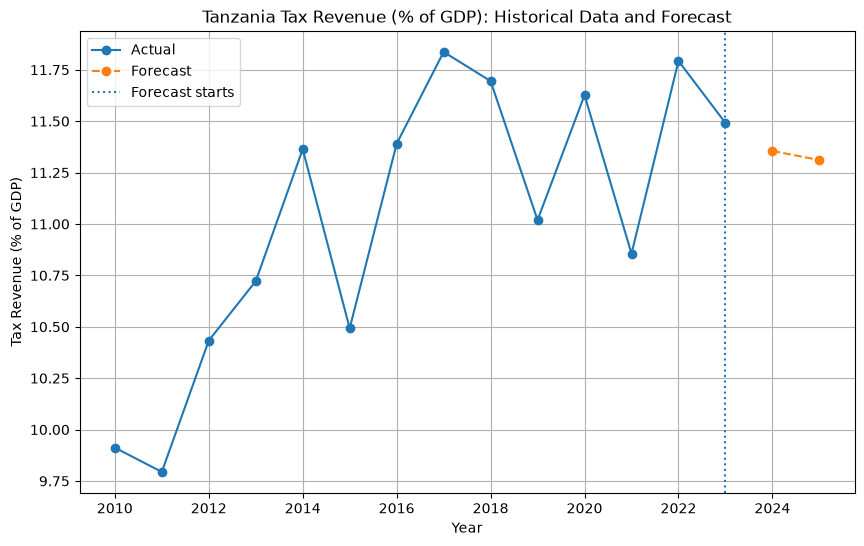

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

actual_data = forecast_table[
    forecast_table["Type"] == "Actual"
]

forecast_data = forecast_table[
    forecast_table["Type"] == "Forecast"
]

plt.plot(
    actual_data["year"],
    actual_data["Tax Revenue (% of GDP)"],
    marker="o",
    label="Actual"
)

plt.plot(
    forecast_data["year"],
    forecast_data["Tax Revenue (% of GDP)"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.axvline(
    x=2023,
    linestyle=":",
    label="Forecast starts"
)

plt.xlabel("Year")
plt.ylabel("Tax Revenue (% of GDP)")
plt.title(
    "Tanzania Tax Revenue (% of GDP): "
    "Historical Data and Forecast"
)

plt.legend()
plt.grid(True)
plt.show()

## 30. Historical Model Predictions

The final lag-based model is also used to generate predictions for the historical observations available to the model.

These predictions are compared with the actual tax revenue values to assess how closely the model fits the historical data.

In [64]:
historical_results = lag2_data[
    ["year", "Tax Revenue (% of GDP)"]
].copy()

historical_results["Predicted"] = final_model.predict(
    lag2_data[
        ["Tax Revenue Lag 1", "Tax Revenue Lag 2"]
    ]
)

historical_results["Error"] = (
    historical_results["Tax Revenue (% of GDP)"]
    - historical_results["Predicted"]
)

historical_results["Absolute Error"] = (
    historical_results["Error"].abs()
)

historical_results

,year,Tax Revenue (% of GDP),Predicted,Error,Absolute Error
3186,2012,10.433004,11.022071,-0.589067,0.589067
3187,2013,10.721923,11.050014,-0.328090,0.328090
3188,2014,11.363797,11.144341,0.219456,0.219456
3189,2015,10.492495,11.220508,-0.728012,0.728012
3190,2016,11.390340,11.239105,0.151235,0.151235
3191,2017,11.836719,11.195183,0.641536,0.641536
3192,2018,11.695083,11.330367,0.364716,0.364716
3193,2019,11.019117,11.373740,-0.354623,0.354623
3194,2020,11.626769,11.312713,0.314056,0.314056
3195,2021,10.855800,11.272809,-0.417009,0.417009


In [65]:
historical_mae = mean_absolute_error(
    historical_results["Tax Revenue (% of GDP)"],
    historical_results["Predicted"]
)

historical_rmse = np.sqrt(
    mean_squared_error(
        historical_results["Tax Revenue (% of GDP)"],
        historical_results["Predicted"]
    )
)

print("Historical MAE:", historical_mae)
print("Historical RMSE:", historical_rmse)

Historical MAE: 0.40280032571576996
Historical RMSE: 0.43768769024549503


In [66]:
%whos

Variable                   Type                Data/Info
--------------------------------------------------------
LinearRegression           ABCMeta             <class 'sklearn.linear_mo<...>._base.LinearRegression'>
Ridge                      ABCMeta             <class 'sklearn.linear_model._ridge.Ridge'>
TimeSeriesSplit            ABCMeta             <class 'sklearn.model_sel<...>._split.TimeSeriesSplit'>
X                          DataFrame           Shape: (14, 10)
X_2024                     DataFrame           Shape: (1, 2)
X_2025                     DataFrame           Shape: (1, 2)
X_final                    DataFrame           Shape: (12, 2)
X_lag2_test                DataFrame           Shape: (3, 2)
X_lag2_train               DataFrame           Shape: (9, 2)
X_lag_test                 DataFrame           Shape: (3, 1)
X_lag_train                DataFrame           Shape: (10, 1)
X_test                     DataFrame           Shape: (3, 10)
X_test_cv                  DataFram

In [67]:
actual_data


,year,Tax Revenue (% of GDP),Type
3184,2010,9.912262,Actual
3185,2011,9.793982,Actual
3186,2012,10.433004,Actual
3187,2013,10.721923,Actual
3188,2014,11.363797,Actual
3189,2015,10.492495,Actual
3190,2016,11.390340,Actual
3191,2017,11.836719,Actual
3192,2018,11.695083,Actual
3193,2019,11.019117,Actual


## 31. Saving the Trained Model

The trained model is saved using `joblib`.

Saving the model allows it to be reused later without retraining it from the beginning.

In [68]:
import joblib

final_model = joblib.load("tra_tax_revenue_model.pkl")
features = joblib.load("tra_model_features.pkl")

In [69]:
import joblib

joblib.dump(final_model, "tra_tax_revenue_model.pkl")

['tra_tax_revenue_model.pkl']

## 32. Saving the Model Features

The feature information used by the model is saved separately.

This helps preserve the structure required when the trained model is later loaded and used for prediction.

In [70]:
joblib.dump(features, "tra_model_features.pkl")

['tra_model_features.pkl']